# Import packages and libraries

In [38]:

# Package imports
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# For grid cell creation
from shapely.geometry import Polygon

# Setup Directories

In [39]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = Path(CURRENT_DIRECTORY).parents[1] / "AED-OHCA" /"datasets"

display(CURRENT_DIRECTORY)
display(BASE_DATASET_PATH   )

PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/dr_sean_code')

PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets')

# Load the Point-Level GeoPackage

In [40]:
ohca_filepath = BASE_DATASET_PATH/"3_OHCA_with_geometric_pts.gpkg"
gdf_ohca = gpd.read_file(ohca_filepath)

display(gdf_ohca.head())

,Case #,Site #,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Time call received at dispatch center,Estimated time of arrest,lat,lon,geometry
0,SGSIN0213,2,2010-04-01,470146.0,None,Home Residence,HDB Level 7,23:29:17,23:35:00,1.334604,103.911889,POINT (36744.065 35199.375)
1,SGSIN0218,2,2010-04-01,520926.0,None,Home Residence,HDB Level 2,14:18:54,14:05:00,1.346122,103.940989,POINT (39982.538 36473.112)
2,SGSIN6480,6,2010-04-01,560565.0,None,Healthcare Facility,NKF Dialysis Centre,16:35:03,16:30:00,1.369882,103.858475,POINT (30799.605 39100.122)
3,SGSIN5332,5,2010-04-02,680626.0,None,Home Residence,HDB Level 7,02:28:08,02:00:00,1.398315,103.745837,POINT (18264.472 42244.265)
4,SGSIN0214,2,2010-04-03,468963.0,None,Place of Recreation,East Coast Park NSC Carpark,08:56:21,09:00:00,1.315317,103.961890,POINT (42308.771 33066.957)


# Standardize Time and Filter from 2019 to 2021

Replace 'INC_CREATE_TIME' with PAROS 'Date of Incident'

In [41]:
gdf_ohca['Date of Incident'] = pd.to_datetime(gdf_ohca['Date of Incident'],
                                              format='mixed')
df_2019_to_2021 = gdf_ohca[gdf_ohca['Date of Incident'].dt.year.between(2019, 2021)].copy()
display(df_2019_to_2021.head())

,Case #,Site #,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Time call received at dispatch center,Estimated time of arrest,lat,lon,geometry
17665,SGSIN01135791,1,2019-01-01,670516.0,None,Home Residence,None,09:30:41,09:30:00,1.387268,103.767236,POINT (20645.861 41022.665)
17666,SGSIN01135792,1,2019-01-01,670253.0,None,Home Residence,None,20:13:32,20:00:00,1.379610,103.774588,POINT (21464.023 40175.861)
17667,SGSIN01135793,1,2019-01-01,680668.0,None,Home Residence,None,23:41:32,23:40:00,1.401803,103.749333,POINT (18653.533 42629.937)
17668,SGSIN02136384,2,2019-01-01,416823.0,None,In EMS/Private ambulance,None,15:46:02,16:23:00,1.320074,103.911580,POINT (36709.728 33592.73)
17669,SGSIN04136999,4,2019-01-01,735689.0,None,Home Residence,None,16:10:16,16:05:00,1.443868,103.808552,POINT (25243.867 47281.12)


# CRS Verification

Ensure that the pointas are in SVY21 (EPSG:3414) for accurate hectare grid calculation

In [42]:
if df_2019_to_2021.crs != "EPSG:3414":
    df_2019_to_2021 = df_2019_to_2021.to_crs(epsg=3414)

print(f"Successfully loaded {len(df_2019_to_2021)} OHCA points for the 2019-2021 simulation grid.")
display(df_2019_to_2021[['Case #', 'Date of Incident', 'geometry']].head())

Successfully loaded 9962 OHCA points for the 2019-2021 simulation grid.


,Case #,Date of Incident,geometry
17665,SGSIN01135791,2019-01-01,POINT (20645.861 41022.665)
17666,SGSIN01135792,2019-01-01,POINT (21464.023 40175.861)
17667,SGSIN01135793,2019-01-01,POINT (18653.533 42629.937)
17668,SGSIN02136384,2019-01-01,POINT (36709.728 33592.73)
17669,SGSIN04136999,2019-01-01,POINT (25243.867 47281.12)


# Define extent (bounding box) of the grid

Take the minimum and maximum coordinates of the 2019-2021 OHCA points

In [43]:
xmin, ymin, xmax, ymax = df_2019_to_2021.total_bounds
display(xmin, ymin, xmax, ymax)

np.float64(3616.5933423814167)

np.float64(25121.36140110203)

np.float64(46782.8845840514)

np.float64(49925.082729268266)

# Create a grid of 30 x 20 and calculate the width and height of each individual grid cell

In [44]:
n_cols = 30
n_rows = 20

cell_width = (xmax - xmin) / n_cols
cell_height = (ymax - ymin) / n_rows

display(cell_width, cell_height)

np.float64(1438.8763747223327)

np.float64(1240.186066408312)

# Creating the Grid Geometry

Since NetLogo coordinates usually start from bottom-left, will need o calculate the actual map coordinates for the specific cell before creating a polygon square

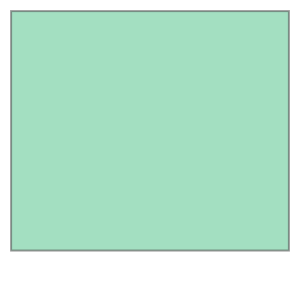

In [45]:
grid_cells = []

for y_idx in range(n_rows):
    for x_idx in range(n_cols):
        x0 = xmin + x_idx * cell_width
        y0 = ymin + y_idx * cell_height
        x1 = x0 + cell_width
        y1 = y0 + cell_height

        grid_cells.append(Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)]))

display(grid_cells[0])

# Convert to GeoDataFram and assign NetLogo patch coordinates

Creating pxcor and pycor -> Defines a patch's fixed location where pxcor increases to the right and pycor increases upwards

In [46]:
grids_gdf = gpd.GeoDataFrame(geometry=grid_cells,
                            crs="EPSG:3414")
grids_gdf['pxcor'] = np.tile(np.arange(n_cols), n_rows)
grids_gdf['pycor'] = np.repeat(np.arange(n_rows), n_cols)

display(grids_gdf['pxcor'])
display(grids_gdf['pycor'])

0       0
1       1
2       2
3       3
4       4
       ..
595    25
596    26
597    27
598    28
599    29
Name: pxcor, Length: 600, dtype: int64

0       0
1       0
2       0
3       0
4       0
       ..
595    19
596    19
597    19
598    19
599    19
Name: pycor, Length: 600, dtype: int64

# Perform spatial join

To map every OHCA poin to the grid cell it falls inside

In [47]:
merged_df = gpd.sjoin(df_2019_to_2021,
                      grids_gdf,
                      how='inner',
                      predicate='within')

display(merged_df.head())

,Case #,Site #,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Time call received at dispatch center,Estimated time of arrest,lat,lon,geometry,index_right,pxcor,pycor
17665,SGSIN01135791,1,2019-01-01,670516.0,None,Home Residence,None,09:30:41,09:30:00,1.387268,103.767236,POINT (20645.861 41022.665),371,11,12
17666,SGSIN01135792,1,2019-01-01,670253.0,None,Home Residence,None,20:13:32,20:00:00,1.379610,103.774588,POINT (21464.023 40175.861),372,12,12
17667,SGSIN01135793,1,2019-01-01,680668.0,None,Home Residence,None,23:41:32,23:40:00,1.401803,103.749333,POINT (18653.533 42629.937),430,10,14
17668,SGSIN02136384,2,2019-01-01,416823.0,None,In EMS/Private ambulance,None,15:46:02,16:23:00,1.320074,103.911580,POINT (36709.728 33592.73),202,22,6
17669,SGSIN04136999,4,2019-01-01,735689.0,None,Home Residence,None,16:10:16,16:05:00,1.443868,103.808552,POINT (25243.867 47281.12),525,15,17


# Checking counts of incidents per cell

In [48]:
grid_counts = merged_df.groupby(['pxcor', 'pycor']).size().reset_index(name='incident_count')
display(grid_counts.head())

,pxcor,pycor,incident_count
0,0,4,7
1,0,6,3
2,1,2,2
3,1,3,1
4,1,4,2


# Merging the counts back onto the master grid

In [49]:
final_grid = grids_gdf.merge(grid_counts,
                             on=['pxcor','pycor'],
                             how='left')
final_grid['incident_count'] = final_grid['incident_count'].fillna(0)

print(f"Total raw incidents from 2019 - 2021: {final_grid['incident_count'].sum()}")

Total raw incidents from 2019 - 2021: 9961.0


# Calculate 3 Year Annual Average

In [50]:
final_grid['incident_count'] = final_grid['incident_count'] / 3.0

print(f"Generated a {n_cols}x{n_rows} grid ({len(final_grid)} total patches).")
print(f"Average annual OHCA incidents mapped into the grid: {final_grid['incident_count'].sum()}")

Generated a 30x20 grid (600 total patches).
Average annual OHCA incidents mapped into the grid: 3320.333333333333


# Export for NetLogo

In [51]:
export_path = BASE_DATASET_PATH / "singapore_data/cleaned_data/ohca_data/grid_2019_2021_avg_counts_for_netlogo.csv"

final_grid[['pxcor', 'pycor', 'incident_count']].to_csv(export_path, index=False)
print(f"Ready for simulation! Exported to: {export_path}")

Ready for simulation! Exported to: /Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/singapore_data/cleaned_data/ohca_data/grid_2019_2021_avg_counts_for_netlogo.csv


# To identify the exact neighborhoods of the Hot spots

In [57]:
subzones_path = BASE_DATASET_PATH / "singapore_data/data_gov/masterplan_2019/subzone_boundary_2019.gpkg"
subzones = gpd.read_file(subzones_path)

# Ensure the maps use the same coordinate reference system (SVY21)
subzones = subzones.to_crs(final_grid.crs)

display (subzones.head())

,Name,Description,SUBZONE_N,PLN_AREA_N,geometry
0,kml_1,<center><table><tr><th colspan='2' align='cent...,DEPOT ROAD,BUKIT MERAH,"MULTIPOLYGON Z (((25910.344 29425.34 0, 26265...."
1,kml_2,<center><table><tr><th colspan='2' align='cent...,BUKIT MERAH,BUKIT MERAH,"MULTIPOLYGON Z (((26750.092 29216.098 0, 26751..."
2,kml_3,<center><table><tr><th colspan='2' align='cent...,CHINATOWN,OUTRAM,"MULTIPOLYGON Z (((29161.201 29723.071 0, 29189..."
3,kml_4,<center><table><tr><th colspan='2' align='cent...,PHILLIP,DOWNTOWN CORE,"MULTIPOLYGON Z (((29814.107 29616.894 0, 29806..."
4,kml_5,<center><table><tr><th colspan='2' align='cent...,RAFFLES PLACE,DOWNTOWN CORE,"MULTIPOLYGON Z (((30137.768 29843.194 0, 30138..."


# Get top 10 most severe grid cells

In [59]:
top_grids = final_grid.sort_values(by='incident_count', ascending=False).head(10).copy()
display(top_grids)

,geometry,pxcor,pycor,incident_count
234,"POLYGON ((38149.626 33802.664, 39588.503 33802...",24,7,65.666667
106,"POLYGON ((26638.615 28841.92, 28077.492 28841....",16,3,52.333333
258,"POLYGON ((29516.368 35042.85, 30955.244 35042....",18,8,51.000000
412,"POLYGON ((35271.874 41243.78, 36710.75 41243.7...",22,13,50.000000
371,"POLYGON ((19444.233 40003.594, 20883.11 40003....",11,12,49.000000
285,"POLYGON ((25199.739 36283.036, 26638.615 36283...",15,9,48.333333
348,"POLYGON ((29516.368 38763.408, 30955.244 38763...",18,11,45.666667
351,"POLYGON ((33832.997 38763.408, 35271.874 38763...",21,11,45.000000
295,"POLYGON ((39588.503 36283.036, 41027.379 36283...",25,9,44.333333
296,"POLYGON ((41027.379 36283.036, 42466.255 36283...",26,9,44.000000


# Creating a point exactly in the middle of each grid

Need to perform a spatial join between the hotspot centers and the subzone boundary

In [60]:
top_grids['centroid'] = top_grids.geometry.centroid
top_grids_centroids = top_grids.set_geometry('centroid')
hotspot_neighborhoods = gpd.sjoin(top_grids_centroids,
                                  subzones,
                                  how='left',
                                  predicate='within')

# Standardize column names if they are uppercase
hotspot_neighborhoods.columns = hotspot_neighborhoods.columns.str.upper()

print("TOP 10 OHCA HOTSPOT GRIDS (2019-2021)")
display(hotspot_neighborhoods[['PXCOR', 'PYCOR', 'INCIDENT_COUNT', 'SUBZONE_N', 'PLN_AREA_N']])

TOP 10 OHCA HOTSPOT GRIDS (2019-2021)


,PXCOR,PYCOR,INCIDENT_COUNT,SUBZONE_N,PLN_AREA_N
234,24,7,65.666667,BEDOK NORTH,BEDOK
106,16,3,52.333333,TIONG BAHRU STATION,BUKIT MERAH
258,18,8,51.000000,LORONG 8 TOA PAYOH,TOA PAYOH
412,22,13,50.000000,RIVERVALE,SENGKANG
371,11,12,49.000000,SAUJANA,BUKIT PANJANG
285,15,9,48.333333,CENTRAL WATER CATCHMENT,CENTRAL WATER CATCHMENT
348,18,11,45.666667,CHENG SAN,ANG MO KIO
351,21,11,45.000000,HOUGANG CENTRAL,HOUGANG
295,25,9,44.333333,TAMPINES EAST,TAMPINES
296,26,9,44.000000,TAMPINES EAST,TAMPINES


# Plotting heatmap over the actual map of Singapore

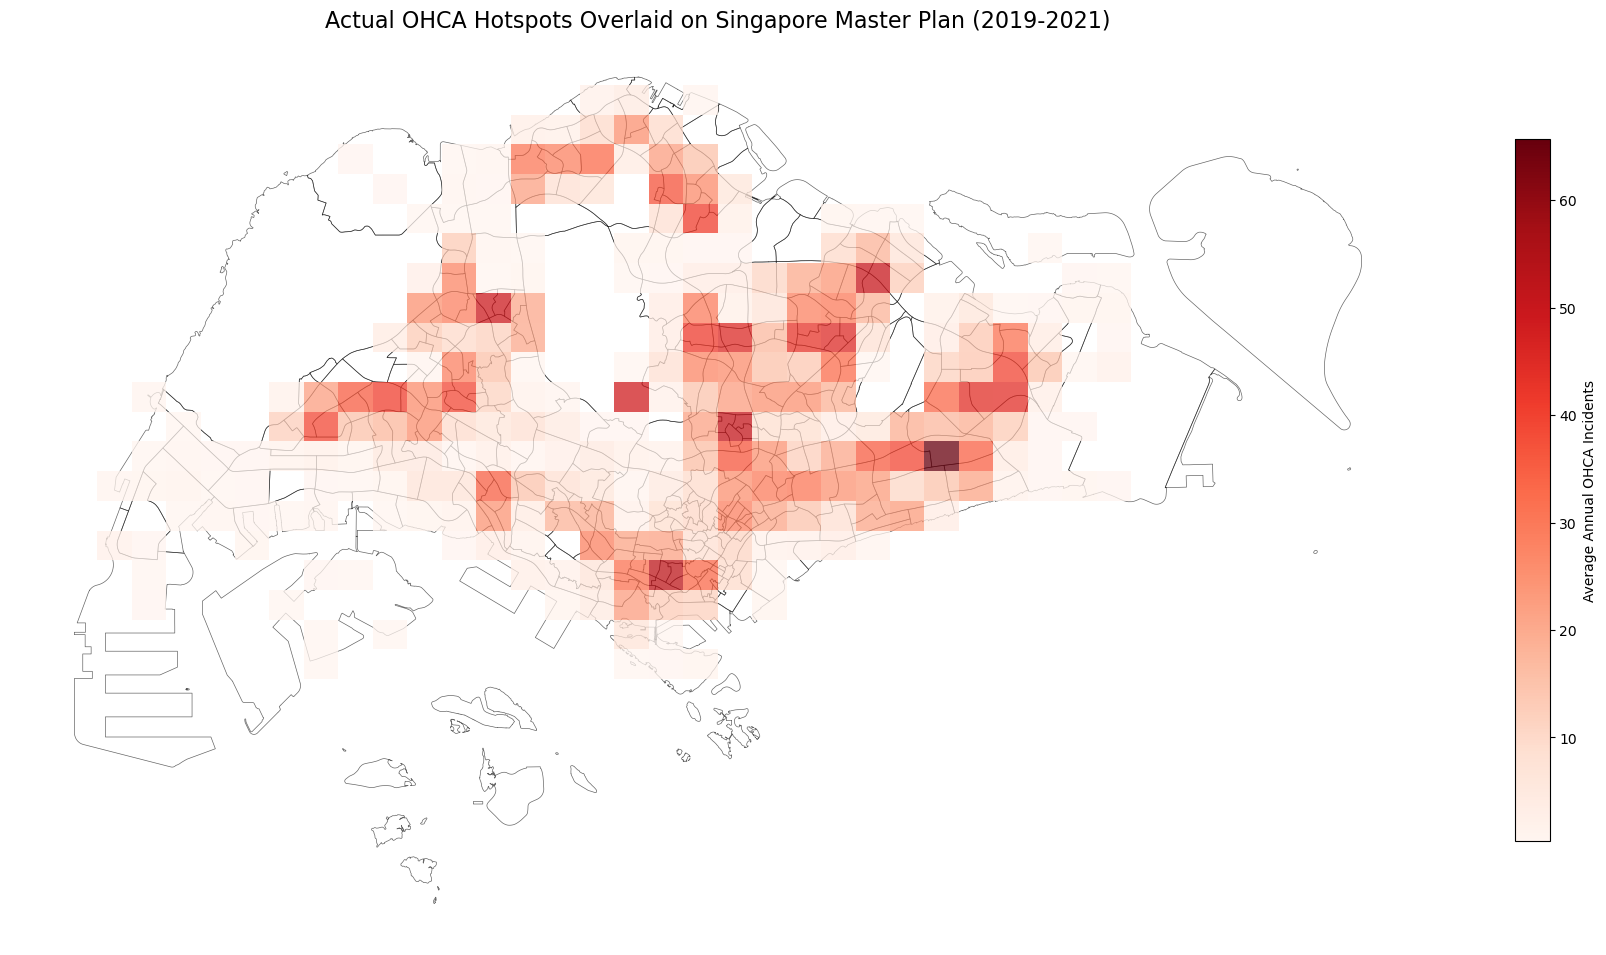

TOP 10 HIGHEST OHCA INCIDENT NEIGHBORHOODS (2019-2021)


,Grid X,Grid Y,Avg Annual Incidents,Subzone Name,Planning Area Name
0,24,7,65.7,BEDOK NORTH,BEDOK
1,16,3,52.3,TIONG BAHRU STATION,BUKIT MERAH
2,18,8,51.0,LORONG 8 TOA PAYOH,TOA PAYOH
3,22,13,50.0,RIVERVALE,SENGKANG
4,11,12,49.0,SAUJANA,BUKIT PANJANG
5,15,9,48.3,CENTRAL WATER CATCHMENT,CENTRAL WATER CATCHMENT
6,18,11,45.7,CHENG SAN,ANG MO KIO
7,21,11,45.0,HOUGANG CENTRAL,HOUGANG
8,25,9,44.3,TAMPINES EAST,TAMPINES
9,26,9,44.0,TAMPINES EAST,TAMPINES


In [68]:
fig, ax = plt.subplots(figsize=(18, 12))

# Plot the base map of Singapore (Subzone boundaries)
subzones.plot(ax=ax,
              facecolor='none',
              edgecolor='black',
              linewidth=0.5,
              alpha=0.6)

# Plot the heatmap grid directly over the map
active_grids = final_grid[final_grid['incident_count'] > 0]
active_grids.plot(
    column='incident_count', 
    ax=ax, 
    cmap='Reds', 
    alpha=0.75,
    edgecolor='none',
    legend=True,
    legend_kwds={'label': "Average Annual OHCA Incidents", 'shrink': 0.6}
)

plt.title('Actual OHCA Hotspots Overlaid on Singapore Master Plan (2019-2021)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Create a summary table for the output
summary_table = hotspot_neighborhoods[['PXCOR',
                                       'PYCOR',
                                       'INCIDENT_COUNT',
                                       'SUBZONE_N',
                                       'PLN_AREA_N']].copy()

# Rename the columns for easier reading
summary_table.columns = ['Grid X',
                         'Grid Y',
                         'Avg Annual Incidents',
                         'Subzone Name',
                         'Planning Area Name']

# Format the table
summary_table = summary_table.sort_values(by='Avg Annual Incidents',
                                          ascending=False).reset_index(drop=True)
summary_table['Avg Annual Incidents'] = summary_table['Avg Annual Incidents'].round(1)

print("TOP 10 HIGHEST OHCA INCIDENT NEIGHBORHOODS (2019-2021)")
display(summary_table)
